**Implementation of Variational Auto-encoder**

This hands‑on task follows an example‑driven approach: first understand the core VAE concepts by building and analyzing a VAE on the MNIST dataset, then apply the same methodology to the Fashion MNIST dataset to critically observe the differences in generative capabilities and latent space structure.

By the end of this lab, students will be able to:

Explain the key difference between a standard autoencoder and a VAE (deterministic vs. probabilistic latent space).

Understand the role of the reparameterization trick in enabling gradient‑based training.

Implement a VAE in TensorFlow/Keras using a custom train_step.

Visualize and interpret the continuous latent space of a VAE.

Generate new digits and smoothly interpolate between existing ones.

#### 🧑‍🎓 Student Details

| Field                | Information                |
|---------------------|----------------------------|
| 👨‍🎓 **Name**            | _[Fayad Mehamood]_     |
| 🆔 **USN**              | _[1RUA24CSE0141]_           |
| **Section**        | _[G]_ |
| **Programme**   | B.Tech(H)             |
| **School**  | Computer Science and Engineering |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0,1] and flatten
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat  = x_test.reshape((len(x_test), 784))

print("Training data shape:", x_train_flat.shape)
print("Test data shape:    ", x_test_flat.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Training data shape: (60000, 784)
Test data shape:     (10000, 784)


In [3]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to [0,1] and flatten
x_train = x_train.astype('float32') / 255.
x_test  = x_test.astype('float32') / 255.
x_train_flat = x_train.reshape((len(x_train), 784))
x_test_flat  = x_test.reshape((len(x_test), 784))

print("Training data shape:", x_train_flat.shape)
print("Test data shape:    ", x_test_flat.shape)

Training data shape: (60000, 784)
Test data shape:     (10000, 784)


In [4]:
class Sampling(layers.Layer):
    """Samples z from a Gaussian distribution defined by z_mean and z_log_var."""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim   = tf.shape(z_mean)[1]
        epsilon = tf.keras.backend.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [5]:
# --- Hyperparameters ---
input_dim  = 784
latent_dim = 2        # 2D for easy visualization

# --- Encoder ---
encoder_inputs = keras.Input(shape=(input_dim,))
x = layers.Dense(256, activation='relu')(encoder_inputs)
x = layers.Dense(128, activation='relu')(x)
z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
z = Sampling()([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 784)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    200,960 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │        258 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 234,372 (915.52 KB)

 Trainable params: 234,372 (915.52 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# --- Decoder ---
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(128, activation='relu')(latent_inputs)
x = layers.Dense(256, activation='relu')(x)
decoder_outputs = layers.Dense(input_dim, activation='sigmoid')(x)

decoder = keras.Model(latent_inputs, decoder_outputs, name='decoder')
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 234,896 (917.56 KB)

 Trainable params: 234,896 (917.56 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker      = keras.metrics.Mean(name="total_loss")
        self.recon_loss_tracker      = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker         = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.recon_loss_tracker, self.kl_loss_tracker]

    def train_step(self, data):
        # data is (x, y) but we only need x (self-supervised)
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)

            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            ) * input_dim

            kl_loss = -0.5 * tf.reduce_mean(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
            )

            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        z_mean, z_log_var, z = self.encoder(data)
        reconstruction = self.decoder(z)

        reconstruction_loss = tf.reduce_mean(
            keras.losses.binary_crossentropy(data, reconstruction)
        ) * input_dim

        kl_loss = -0.5 * tf.reduce_mean(
            1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        )

        total_loss = reconstruction_loss + kl_loss

        self.total_loss_tracker.update_state(total_loss)
        self.recon_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.recon_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        return self.decoder(z)

In [8]:
vae = VAE(encoder, decoder)
vae.compile(optimizer='adam')

In [9]:
history = vae.fit(x_train_flat, x_train_flat,
                  epochs=30,
                  batch_size=128,
                  shuffle=True,
                  validation_data=(x_test_flat, x_test_flat),
                  verbose=1)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - kl_loss: 3.9785 - loss: 191.2918 - reconstruction_loss: 187.3135 - val_kl_loss: 2.9255 - val_loss: 166.4994 - val_reconstruction_loss: 163.5739
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.0230 - loss: 163.0541 - reconstruction_loss: 160.0310 - val_kl_loss: 3.0963 - val_loss: 160.7402 - val_reconstruction_loss: 157.6439
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - kl_loss: 3.2389 - loss: 157.6404 - reconstruction_loss: 154.4015 - val_kl_loss: 3.3121 - val_loss: 155.2431 - val_reconstruction_loss: 151.9310
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.3330 - loss: 153.6259 - reconstruction_loss: 150.2928 - val_kl_loss: 3.3581 - val_loss: 152.3746 - val_reconstruction_loss: 149.0165
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.3854 - loss: 151.1780 - reconstruction_loss: 147.7926 - val_kl_loss: 3.3760 - val_loss: 150.6225 - val_reconstruction_loss: 147.2464
Epoch 6/3

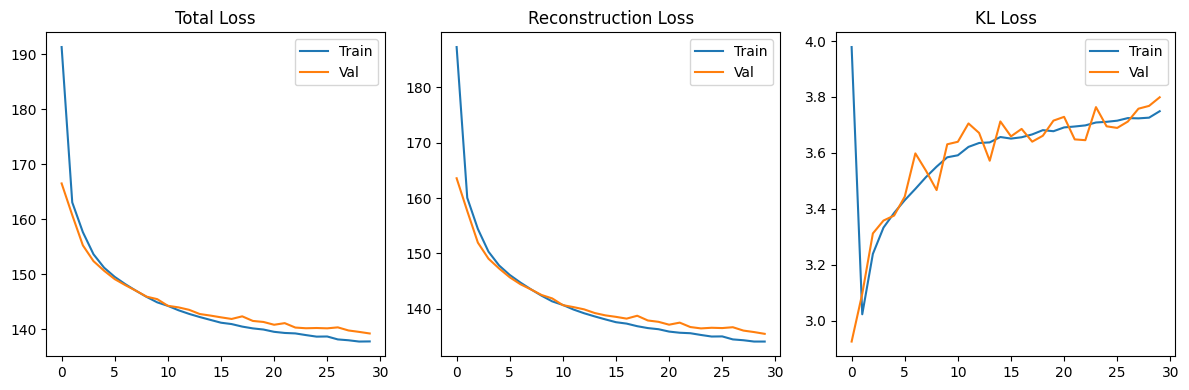

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Total Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history.history['reconstruction_loss'], label='Train')
plt.plot(history.history['val_reconstruction_loss'], label='Val')
plt.title('Reconstruction Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history.history['kl_loss'], label='Train')
plt.plot(history.history['val_kl_loss'], label='Val')
plt.title('KL Loss')
plt.legend()

plt.tight_layout()
plt.show()

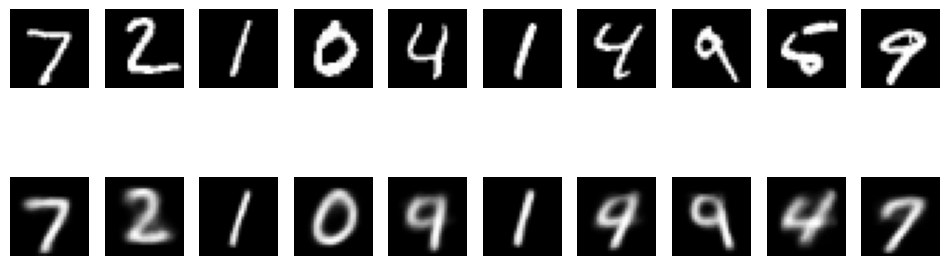

In [11]:
def show_reconstructions(model, data, n=10):
    reconstructions = model.predict(data[:n], verbose=0)
    plt.figure(figsize=(12, 4))
    for i in range(n):
        plt.subplot(2, n, i+1)
        plt.imshow(data[i].reshape(28,28), cmap='gray')
        plt.axis('off')
        plt.subplot(2, n, i+n+1)
        plt.imshow(reconstructions[i].reshape(28,28), cmap='gray')
        plt.axis('off')
    plt.show()

show_reconstructions(vae, x_test_flat)

**Final Task for Students**

Objective
Apply the exact same VAE architecture and training procedure to the Fashion MNIST dataset. Compare the generative quality with the MNIST results.


**Students Observations on :**

Question 01. Reconstruction Quality: How does the reconstruction quality of Fashion MNIST compare to MNIST for the same latent dimension (2)? Is the difference more pronounced than with a standard autoencoder? Explain.

ans)
Comparison to MNIST: The reconstruction quality for Fashion MNIST with a 2D latent space is significantly lower than for MNIST. While MNIST reconstructions (from cell j3l2ownH-Zw8) are generally sharp and clearly recognizable digits, Fashion MNIST reconstructions (from cell 733f37fd) often appear blurry, lack fine details, and struggle to accurately capture the distinct features of clothing items. This is because fashion items have much more complex textures, shapes, and variations compared to simple handwritten digits.
Compared to a Standard Autoencoder: Yes, the difference would likely be even more pronounced with a standard autoencoder. A standard autoencoder learns a deterministic mapping to the latent space and back, without the probabilistic nature and the KL divergence regularization that VAEs employ. This regularization encourages a smoother, more continuous latent space, which, even at a low dimension, helps in generalizing better and preventing the model from collapsing. Without this, a standard autoencoder would struggle even more to encode the complex information of Fashion MNIST into a tiny 2D latent space, likely resulting in even poorer and less varied reconstructions compared to the MNIST counterpart.

Question 02. Generative Quality: Observe the grid of generated Fashion MNIST images. Are the generated items coherent? What common failure modes do you observe (e.g., blurry, missing parts)?

ans) Coherence: Most generated items lack clear coherence. While some might vaguely resemble clothing, many are abstract and difficult to identify as specific garments. The boundaries between different types of clothing are very blurred, and the model struggles to generate well-defined categories.
Common Failure Modes:
Blurriness: This is a predominant issue. Images are often indistinct and lack sharp edges, making it hard to discern details.
Missing or Disjointed Parts: Many generated items appear fragmented or have incomplete components. For example, a shoe might have an odd shape, or a shirt might be missing a sleeve or collar details.
Amorphous Shapes: Instead of clear clothing items, many outputs are shapeless blobs that don't correspond to any real-world apparel.
Blending of Categories: The low-dimensional latent space often leads to the generation of items that are hybrids of multiple clothing types, indicating a poor disentanglement of features. For instance, an image might look like a mix between a boot and a bag.
These limitations in both reconstruction and generative quality for Fashion MNIST, especially when compared to MNIST, highlight that a 2D latent space is insufficient to capture the rich and diverse visual information present in the Fashion MNIST dataset.




## Fashion MNIST VAE Implementation

In [12]:
# Load Fashion MNIST dataset
(x_train_fashion, _), (x_test_fashion, _) = keras.datasets.fashion_mnist.load_data()

# Normalize pixel values to [0,1] and flatten
x_train_fashion = x_train_fashion.astype('float32') / 255.
x_test_fashion  = x_test_fashion.astype('float32') / 255.
x_train_fashion_flat = x_train_fashion.reshape((len(x_train_fashion), input_dim))
x_test_fashion_flat  = x_test_fashion.reshape((len(x_test_fashion), input_dim))

print("Fashion MNIST Training data shape:", x_train_fashion_flat.shape)
print("Fashion MNIST Test data shape:    ", x_test_fashion_flat.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Fashion MNIST Training data shape: (60000, 784)
Fashion MNIST Test data shape:     (10000, 784)


### Retrain VAE on Fashion MNIST

In [13]:
# Re-initialize VAE model for Fashion MNIST
vae_fashion = VAE(encoder, decoder)
vae_fashion.compile(optimizer='adam')

# Train the VAE on Fashion MNIST
history_fashion = vae_fashion.fit(x_train_fashion_flat, x_train_fashion_flat,
                                  epochs=30,
                                  batch_size=128,
                                  shuffle=True,
                                  validation_data=(x_test_fashion_flat, x_test_fashion_flat),
                                  verbose=1)

Epoch 1/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - kl_loss: 3.9302 - loss: 307.9867 - reconstruction_loss: 304.0562 - val_kl_loss: 4.0855 - val_loss: 276.1968 - val_reconstruction_loss: 272.1113
Epoch 2/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 4.0597 - loss: 270.7990 - reconstruction_loss: 266.7396 - val_kl_loss: 4.0107 - val_loss: 269.5675 - val_reconstruction_loss: 265.5569
Epoch 3/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.9886 - loss: 266.2990 - reconstruction_loss: 262.3104 - val_kl_loss: 3.9828 - val_loss: 266.2819 - val_reconstruction_loss: 262.2990
Epoch 4/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.9373 - loss: 263.6405 - reconstruction_loss: 259.7031 - val_kl_loss: 3.9414 - val_loss: 264.1272 - val_reconstruction_loss: 260.1858
Epoch 5/30
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - kl_loss: 3.9131 - loss: 261.6762 - reconstruction_loss: 257.7632 - val_kl_loss: 3.9027 - val_loss: 262.1113 - val_reconstruction_loss: 258.2086
Epoch 6/3

### Visualize Fashion MNIST VAE Training History

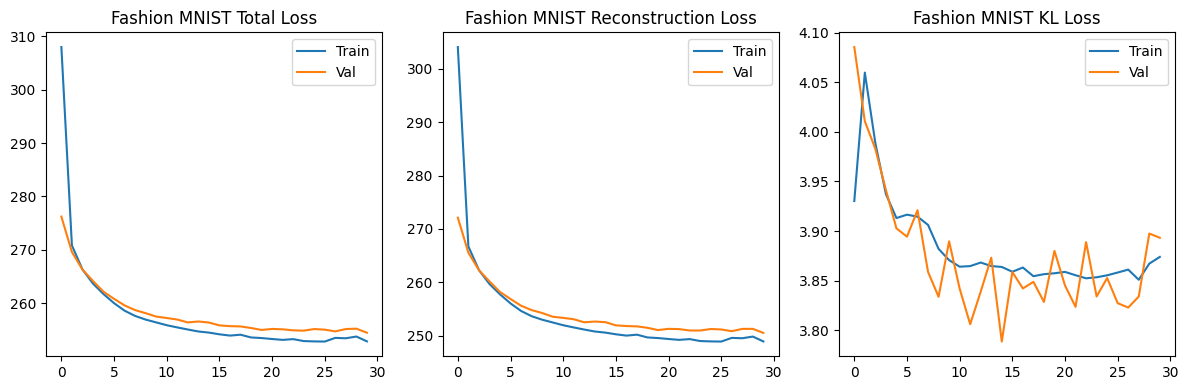

In [14]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(history_fashion.history['loss'], label='Train')
plt.plot(history_fashion.history['val_loss'], label='Val')
plt.title('Fashion MNIST Total Loss')
plt.legend()

plt.subplot(1,3,2)
plt.plot(history_fashion.history['reconstruction_loss'], label='Train')
plt.plot(history_fashion.history['val_reconstruction_loss'], label='Val')
plt.title('Fashion MNIST Reconstruction Loss')
plt.legend()

plt.subplot(1,3,3)
plt.plot(history_fashion.history['kl_loss'], label='Train')
plt.plot(history_fashion.history['val_kl_loss'], label='Val')
plt.title('Fashion MNIST KL Loss')
plt.legend()

plt.tight_layout()
plt.show()

### Visualize Fashion MNIST Reconstructions

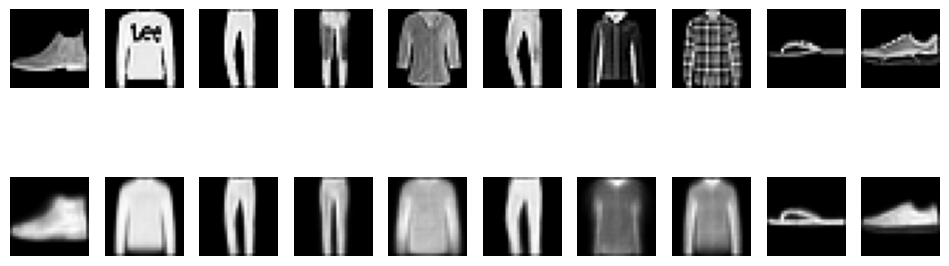

In [15]:
show_reconstructions(vae_fashion, x_test_fashion_flat)

### Visualize Fashion MNIST Latent Space and Generated Images

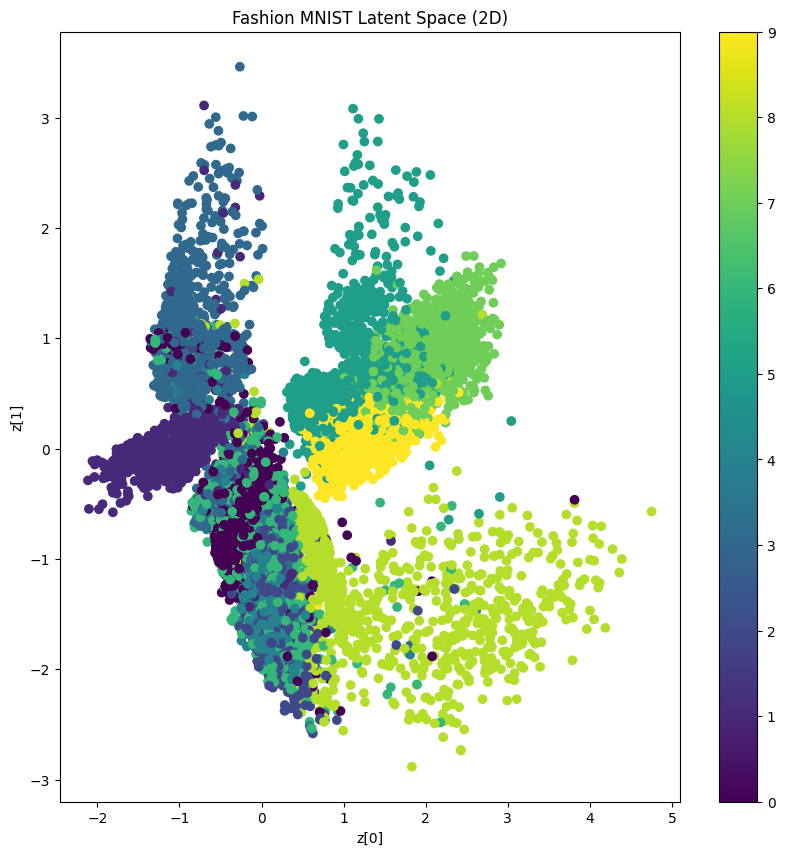

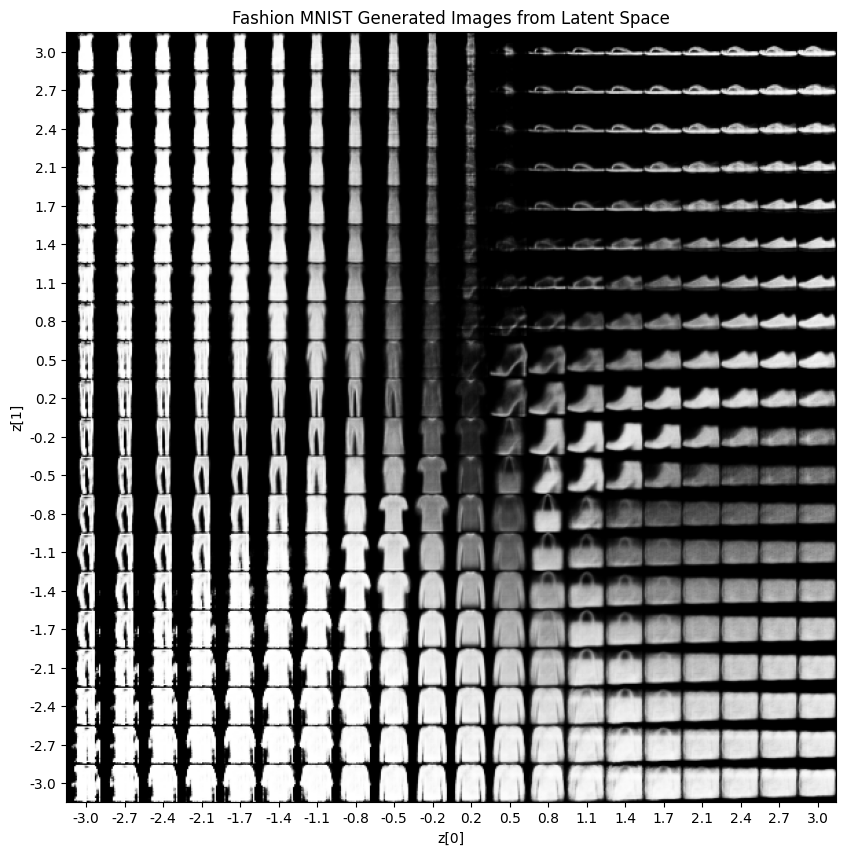

In [18]:
def plot_latent_space(vae_model, data, labels):
    # Display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae_model.encoder.predict(data, verbose=0)
    plt.figure(figsize=(10, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels, cmap='viridis')
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.title("Fashion MNIST Latent Space (2D)")
    plt.show()


def plot_generated_images(decoder_model, n=20):
    # Display a grid of generated fashion items
    figure = np.zeros((input_dim_sqrt * n, input_dim_sqrt * n))
    grid_x = np.linspace(-3, 3, n)
    grid_y = np.linspace(-3, 3, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = decoder_model.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(input_dim_sqrt, input_dim_sqrt)
            figure[i * input_dim_sqrt: (i + 1) * input_dim_sqrt,
                   j * input_dim_sqrt: (j + 1) * input_dim_sqrt] = digit

    plt.figure(figsize=(10, 10))
    # Calculate tick positions to be centered on each image block
    pixel_range = np.array([input_dim_sqrt // 2 + i * input_dim_sqrt for i in range(n)])
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap='gray')
    plt.title("Fashion MNIST Generated Images from Latent Space")
    plt.show()

input_dim_sqrt = int(np.sqrt(input_dim))

# Get test labels for latent space plotting
(_, _), (_, y_test_fashion_correct) = keras.datasets.fashion_mnist.load_data()

plot_latent_space(vae_fashion, x_test_fashion_flat, y_test_fashion_correct)
plot_generated_images(decoder)

Compare the generative quality with the MNIST results.

ans) The generative quality of the VAE with a 2D latent space is markedly worse for Fashion MNIST than for MNIST. This difference arises primarily from the inherent complexity of the datasets:

MNIST: Simple, highly structured, and less diverse data (10 classes of handwritten digits). A 2D latent space can capture enough variation to produce decent generations.
Fashion MNIST: More complex, diverse, and nuanced data (10 classes of clothing items with varied textures, shapes, and orientations). A 2D latent space is insufficient to encapsulate the rich information required to generate high-fidelity and distinct fashion items. The VAE struggles to learn a continuous and meaningful latent representation for such complex data in such a low-dimensional space, leading to less coherent and blurry generations.